# Data Center Electricity Cost Analysis
## Modeling Annual Costs for 20 MW Data Center in PG&E Territory

This notebook analyzes three scenarios:
- **Scenario A**: Metro Baseline (No Flexibility, No Battery)
- **Scenario B**: Rural with Flexible Load
- **Scenario C**: Rural with Battery Energy Storage System (BESS)

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# --- Define Tariff and Battery Parameters ---

# PG&E B-20 Tariff Structure (Secondary Voltage)
b20_rates = {
    'energy_charges': {
        'summer_peak': 0.20832,
        'summer_part_peak': 0.16020,
        'summer_off_peak': 0.12220,
        'winter_peak': 0.17965,
        'winter_off_peak': 0.12189,
        'winter_super_off_peak': 0.04451
    },
    'demand_charges': {
        'summer_peak': 50.19,
        'summer_part_peak': 10.81,
        'summer_max': 43.05,
        'winter_peak': 3.22,
        'winter_max': 43.05
    }
}

# Battery parameters for Scenario C
battery_params = {
    'power_mw': 20,
    'energy_mwh': 80,
    'efficiency': 0.85, 
    'ancillary_rate': 50
}

# Define a function to get the correct TOU period for a given timestamp
# This function is designed to work with localized Pacific Time.
def get_tou_period(dt):
    hour = dt.hour
    month = dt.month
    
    if month >= 6 and month <= 9:  # Summer
        if hour >= 16 and hour < 21:
            return 'summer_peak'
        elif (hour >= 14 and hour < 16) or (hour >= 21 and hour < 23):
            return 'summer_part_peak'
        else:
            return 'summer_off_peak'
    else:  # Winter
        if hour >= 16 and hour < 21:
            return 'winter_peak'
        elif month in [3, 4, 5] and hour >= 9 and hour < 14:
            return 'winter_super_off_peak'
        else:
            return 'winter_off_peak'

# --- Scenario Functions (Updated) ---

def run_scenario_a(df_data, b20_rates):
    df_data = df_data.copy()
    
    # Calculate energy costs
    df_data['energy_cost'] = df_data.apply(
        lambda x: (x['load_mw'] * 1000) * b20_rates['energy_charges'][x['tou_period']], axis=1
    )
    total_energy_cost = df_data['energy_cost'].sum()
    
    # Calculate monthly demand charges
    monthly_demand_costs = []
    for month in df_data.index.month.unique():
        month_data = df_data[df_data.index.month == month]
        
        peak_demand_cost = 0
        if 'peak' in month_data['tou_period'].values:
            peak_demand = month_data[month_data['tou_period'].str.contains('peak')]['load_mw'].max()
            if not pd.isna(peak_demand):
                peak_demand_cost = peak_demand * 1000 * b20_rates['demand_charges']['summer_peak']
            
        part_peak_cost = 0
        if 'part_peak' in month_data['tou_period'].values:
            part_peak_demand = month_data[month_data['tou_period'].str.contains('part_peak')]['load_mw'].max()
            if not pd.isna(part_peak_demand):
                part_peak_cost = part_peak_demand * 1000 * b20_rates['demand_charges']['summer_part_peak']

        max_demand = month_data['load_mw'].max()
        max_demand_cost = max_demand * 1000 * b20_rates['demand_charges']['summer_max']

        monthly_demand_costs.append(peak_demand_cost + part_peak_cost + max_demand_cost)
    
    total_demand_cost = sum(monthly_demand_costs)
    total_annual_cost = total_energy_cost + total_demand_cost
    
    return {
        'total_cost': total_annual_cost,
        'energy_cost': total_energy_cost,
        'demand_cost': total_demand_cost
    }

def run_scenario_b(df_data, b20_rates):
    df_data = df_data.copy()
    
    # NEW LOGIC: Identify curtailment hours when the congestion component is negative
    df_data['is_curtailment'] = df_data['lmp_congestion'] <= 0
    
    # Calculate energy costs (free during curtailment hours)
    df_data['energy_cost_flex'] = df_data.apply(
        lambda x: 0 if x['is_curtailment'] else x['load_mw'] * 1000 * b20_rates['energy_charges'][x['tou_period']], 
        axis=1
    )
    total_energy_cost = df_data['energy_cost_flex'].sum()
    
    # Demand charges remain the same as Scenario A
    scenario_a_result = run_scenario_a(df_data, b20_rates)
    total_demand_cost = scenario_a_result['demand_cost']
    
    total_annual_cost = total_energy_cost + total_demand_cost
    savings = scenario_a_result['total_cost'] - total_annual_cost
    
    curtailment_hours = df_data['is_curtailment'].sum()
    print(f"Curtailment hours identified: {curtailment_hours} ({curtailment_hours/len(df_data)*100:.1f}% of data)")
    
    return {
        'total_cost': total_annual_cost,
        'savings': savings,
        'curtailment_hours': curtailment_hours
    }

def run_scenario_c(df_data, b20_rates, battery_params):
    df_data = df_data.copy()
    
    # Calculate daily arbitrage revenue
    daily_arbitrage = []
    
    for date, daily_df in df_data.groupby(df_data.index.date):
        # NEW LOGIC: Arbitrage is based on the total LMP
        daily_df = daily_df.sort_values('total_lmp')
        
        charge_hours = daily_df.head(4)
      
        charge_cost = (charge_hours['lmp_energy'] + charge_hours['lmp_losses'] + charge_hours['lmp_congestion'] + charge_hours['lmp_ghg']).sum() * battery_params['power_mw'] / 1000
        
        discharge_hours = daily_df.tail(4)
    
        discharge_revenue = (discharge_hours['lmp_energy'] + discharge_hours['lmp_losses'] + discharge_hours['lmp_congestion'] + discharge_hours['lmp_ghg']).sum() * battery_params['power_mw'] * battery_params['efficiency'] / 1000
        
        daily_profit = discharge_revenue - charge_cost
        daily_arbitrage.append(daily_profit)
    
    annual_arbitrage_revenue = sum(daily_arbitrage)
    
    ancillary_revenue = battery_params['power_mw'] * 1000 * battery_params['ancillary_rate']
    
    scenario_b_result = run_scenario_b(df_data, b20_rates)
    base_cost = scenario_b_result['total_cost']
    
    net_cost = base_cost - annual_arbitrage_revenue - ancillary_revenue
    
    return {
        'net_cost': net_cost,
        'base_cost': base_cost,
        'arbitrage_revenue': annual_arbitrage_revenue,
        'ancillary_revenue': ancillary_revenue,
        'total_revenue': annual_arbitrage_revenue + ancillary_revenue
    }

In [65]:
# Function to load and combine all monthly files into a single, clean DataFrame
def load_and_combine_data(directory=".", node_id='TH_NP15_GEN-APND'):
    all_files = glob.glob(os.path.join(directory, "2024*_LMP.csv"))
    
    if not all_files:
        print("No files found matching the pattern '2024*_LMP.csv'.")
        return pd.DataFrame()
        
    df_list = []
    
    for file in all_files:
        print(f"Processing file: {os.path.basename(file)}")
        df = pd.read_csv(file)
        
        df = df[df['NODE_ID'] == node_id].copy()
        
        df = df.pivot(index='INTERVALSTARTTIME_GMT', columns='XML_DATA_ITEM', values='MW')
        df.reset_index(inplace=True)
        
        df_list.append(df)
        
    final_df = pd.concat(df_list, ignore_index=True)
    
    final_df.rename(columns={
        'LMP_PRC': 'total_lmp',
        'LMP_CONG_PRC': 'lmp_congestion',
        'LMP_ENE_PRC': 'lmp_energy',
        'LMP_LOSS_PRC': 'lmp_losses',
        'LMP_GHG_PRC': 'lmp_ghg',
        'INTERVALSTARTTIME_GMT': 'datetime'
    }, inplace=True)
    
    final_df['datetime'] = pd.to_datetime(final_df['datetime'])
    final_df.set_index('datetime', inplace=True)
    
    # CORRECTED LOGIC: Convert the timezone from UTC (implicit in the datetime string)
    # to the Pacific Timezone, which handles PST and PDT automatically.
    final_df = final_df.tz_convert('America/Los_Angeles')
    
    # Add the constant 20 MW load profile
    final_df['load_mw'] = 20.0 * 1.2
    
    # Add TOU period to dataframe using the now-local time
    final_df['tou_period'] = final_df.index.to_series().apply(get_tou_period)

    return final_df[['total_lmp', 'lmp_congestion', 'lmp_energy', 'lmp_losses', 'lmp_ghg', 'load_mw', 'tou_period']]

In [72]:
full_year_df = load_and_combine_data()

if full_year_df.empty:
    print("DataFrame is empty. Cannot run scenarios.")
else:
    print("\nFull year of data combined and prepared successfully.")
    print(full_year_df.head())
    
    print("\nRunning Scenario A: Metro Baseline")
    results_a = run_scenario_a(full_year_df, b20_rates)

    print("\nRunning Scenario B: Rural with Flexible Load")
    results_b = run_scenario_b(full_year_df, b20_rates)

    print("\nRunning Scenario C: Rural with BESS")
    results_c = run_scenario_c(full_year_df, b20_rates, battery_params)

    print("\n--- Final Results ---")
    print(f"Scenario A - Annual Cost: ${results_a['total_cost'] / 1e6:.5f} M")
    print(f"Scenario B - Annual Cost: ${results_b['total_cost'] / 1e6:.5f} M")
    print(f"Scenario C - Net Annual Cost: ${results_c['net_cost'] / 1e6:.5f} M")

    print(f"\nScenario C Revenue Breakdown:")
    print(f"  - Energy Arbitrage:  ${results_c['arbitrage_revenue'] / 1e6:.5f} M")
    #print(f"  - Ancillary Services:  ${results_c['ancillary_revenue'] / 1e6:.5f} M")
    #print(f"  - Total BESS Revenue:  ${results_c['total_revenue'] / 1e6:.5f} M")

Processing file: 202407_LMP.csv
Processing file: 202406_LMP.csv
Processing file: 202404_LMP.csv
Processing file: 202405_LMP.csv
Processing file: 202409_LMP.csv
Processing file: 202410_LMP.csv
Processing file: 202411_LMP.csv
Processing file: 202401_LMP.csv
Processing file: 202408_LMP.csv
Processing file: 202403_LMP.csv
Processing file: 202412_LMP.csv
Processing file: 202402_LMP.csv

Full year of data combined and prepared successfully.
XML_DATA_ITEM              total_lmp  lmp_congestion  lmp_energy  lmp_losses  \
datetime                                                                       
2024-07-01 00:00:00-07:00   37.37000        -0.10137    38.98394    -1.51258   
2024-07-01 01:00:00-07:00   35.00000        -0.04261    36.36257    -1.31996   
2024-07-01 02:00:00-07:00   34.70089        -0.06858    35.60257    -0.83310   
2024-07-01 03:00:00-07:00   34.72449        -0.06281    35.48639    -0.69908   
2024-07-01 04:00:00-07:00   35.00000        -0.08989    35.86090    -0.77101   



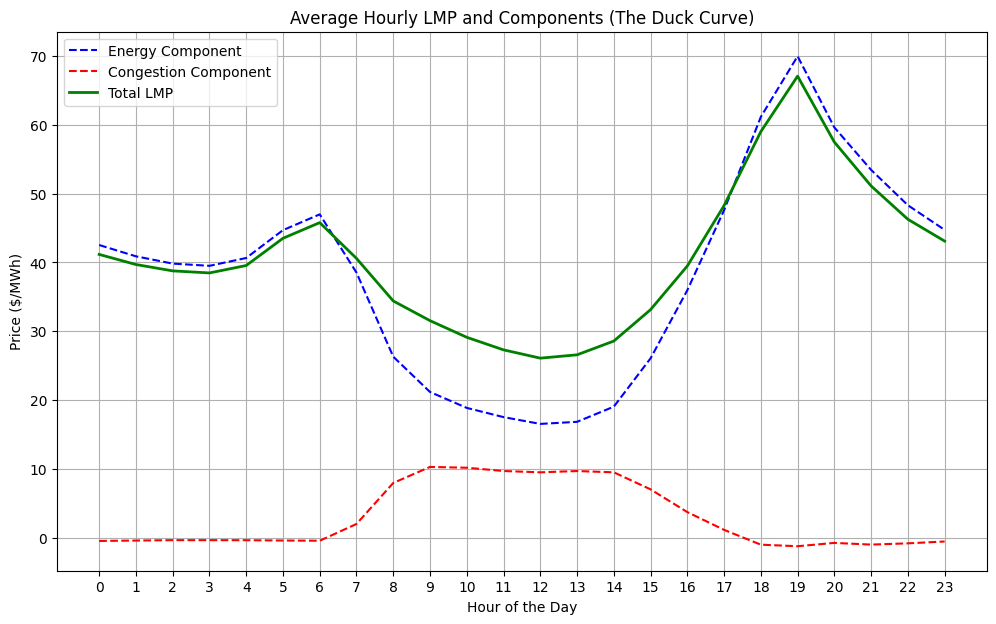

In [30]:
  # --- Visualization Code ---
plt.figure(figsize=(12, 7))
hourly_trends = full_year_df[['lmp_energy', 'lmp_congestion', 'total_lmp']].groupby(full_year_df.index.hour).mean()
plt.plot(hourly_trends.index, hourly_trends['lmp_energy'], label='Energy Component', linestyle='--', color='blue')
plt.plot(hourly_trends.index, hourly_trends['lmp_congestion'], label='Congestion Component', linestyle='--', color='red')
plt.plot(hourly_trends.index, hourly_trends['total_lmp'], label='Total LMP', color='green', linewidth=2)
plt.title('Average Hourly LMP and Components (The Duck Curve)')
plt.xlabel('Hour of the Day')
plt.ylabel('Price ($/MWh)')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.savefig('daily_lmp_trends.png')

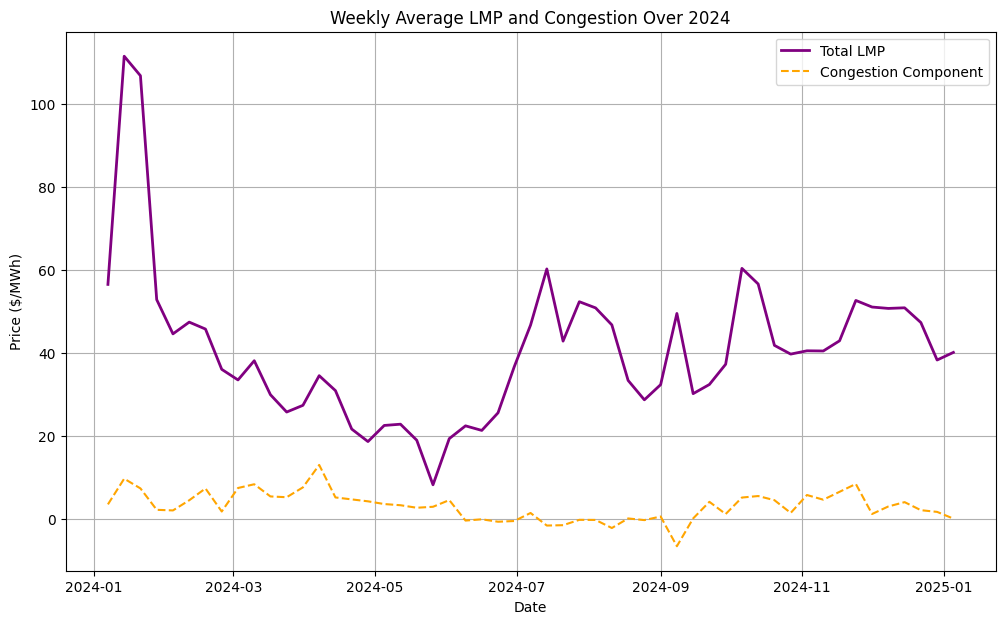

In [31]:
plt.figure(figsize=(12, 7))
weekly_trends = full_year_df[['total_lmp', 'lmp_congestion']].resample('W').mean()
plt.plot(weekly_trends.index, weekly_trends['total_lmp'], label='Total LMP', color='purple', linewidth=2)
plt.plot(weekly_trends.index, weekly_trends['lmp_congestion'], label='Congestion Component', color='orange', linestyle='--')
plt.title('Weekly Average LMP and Congestion Over 2024')
plt.xlabel('Date')
plt.ylabel('Price ($/MWh)')
plt.legend()
plt.grid(True)
plt.savefig('seasonal_lmp_trends.png')

In [40]:
import numpy_financial as npf

def analyze_data_center_scenario(name, discount_rate, initial_capex, period_years,
                                 year_1_revenue, year_1_opex,
                                 revenue_inflation_rate, opex_inflation_rate):
    """
    Performs a comprehensive financial analysis for a data center scenario.
    """
    # --- Generate annual cash flows with inflation ---
    cash_flows = []
    annual_revenues = []
    annual_opex_list = []

    for year in range(1, period_years + 1):
        # Revenue for the year, adjusted for inflation
        current_revenue = year_1_revenue * ((1 + revenue_inflation_rate) ** (year - 1))
        annual_revenues.append(current_revenue)

        # Opex for the year, adjusted for inflation
        current_opex = year_1_opex * ((1 + opex_inflation_rate) ** (year - 1))
        annual_opex_list.append(current_opex)

        # Net cash flow for the year
        net_cash_flow = current_revenue - current_opex
        cash_flows.append(net_cash_flow)

    # --- Calculate Key Metrics ---
    # Combine initial investment with future cash flows
    all_cash_flows = [-initial_capex] + cash_flows

    # 1. Net Present Value (NPV)
    npv = npf.npv(discount_rate, all_cash_flows)

    # 2. Internal Rate of Return (IRR)
    irr = npf.irr(all_cash_flows)

    # 3. Total Cost of Ownership (TCO)
    total_opex = sum(annual_opex_list)
    tco = initial_capex + total_opex

    # 4. Total 10-Year Net Operating Income (Un-discounted)
    total_noi = sum(cash_flows)

    # 5. Discounted Payback Period
    cumulative_discounted_cash_flow = -initial_capex
    payback_period = -1
    for i, cf in enumerate(cash_flows):
        discounted_cf = cf / ((1 + discount_rate) ** (i + 1))
        cumulative_discounted_cash_flow += discounted_cf
        if cumulative_discounted_cash_flow > 0:
            payback_period = (i + 1)
            break

    # --- Print Results ---
    print(f"--- Financial Analysis for: {name} ---")
    print(f"Net Present Value (NPV):      ${npv:,.2f}")
    print(f"Internal Rate of Return (IRR): {irr:.2%}")
    print(f"Total Cost of Ownership (TCO): ${tco:,.2f}")
    print(f"Total Net Operating Income:    ${total_noi:,.2f}")
    if payback_period != -1:
        print(f"Discounted Payback Period:     {payback_period} years")
    else:
        print("Discounted Payback Period:     Does not pay back within the period")
    print("-" * 40)


In [69]:

analyze_data_center_scenario(
    name="Scenario A: Base Case",
    discount_rate=0.066,             # Your required rate of return (8%)
    initial_capex=277815000,          # The total upfront cost of the project
    period_years=10,                # The analysis period
    year_1_revenue=100000000,         # Estimated revenue in the first year
    year_1_opex=39399320,             # Estimated operating expenses in the first year
    revenue_inflation_rate=0.0,     # Annual growth rate of revenue (e.g., 0.01 for 1%)
    opex_inflation_rate=0.03       # Annual growth rate of opex (e.g., 0.025 for 2.5%)
)

--- Financial Analysis for: Scenario A: Base Case ---
Net Present Value (NPV):      $119,513,134.02
Internal Rate of Return (IRR): 15.47%
Total Cost of Ownership (TCO): $729,484,049.43
Total Net Operating Income:    $548,330,950.57
Discounted Payback Period:     6 years
----------------------------------------


In [70]:
analyze_data_center_scenario(
    name="Scenario B",
    discount_rate=0.066,             # Your required rate of return (8%)
    initial_capex=182160000,          # The total upfront cost of the project
    period_years=10,                # The analysis period
    year_1_revenue=60000000,         # Estimated revenue in the first year
    year_1_opex=26281640,             # Estimated operating expenses in the first year
    revenue_inflation_rate=0.0,     # Annual growth rate of revenue (e.g., 0.01 for 1%)
    opex_inflation_rate=0.03       # Annual growth rate of opex (e.g., 0.025 for 2.5%)
)

--- Financial Analysis for: Scenario B ---
Net Present Value (NPV):      $34,898,775.85
Internal Rate of Return (IRR): 10.75%
Total Cost of Ownership (TCO): $483,449,549.07
Total Net Operating Income:    $298,710,450.93
Discounted Payback Period:     8 years
----------------------------------------


In [71]:
analyze_data_center_scenario(
    name="Scenario C",
    discount_rate=0.066,             # Your required rate of return (8%)
    initial_capex=194160000,          # The total upfront cost of the project
    period_years=10,                # The analysis period
    year_1_revenue=60140000,         # Estimated revenue in the first year
    year_1_opex=24780870,             # Estimated operating expenses in the first year
    revenue_inflation_rate=0.0,     # Annual growth rate of revenue (e.g., 0.01 for 1%)
    opex_inflation_rate=0.03       # Annual growth rate of opex (e.g., 0.025 for 2.5%)
)

--- Financial Analysis for: Scenario C ---
Net Present Value (NPV):      $36,021,262.92
Internal Rate of Return (IRR): 10.60%
Total Cost of Ownership (TCO): $478,244,902.91
Total Net Operating Income:    $317,315,097.09
Discounted Payback Period:     8 years
----------------------------------------
